In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 69.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 15.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
thinc 8.3.6 req

In [ ]:
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np
import glob
import os
import gensim
from bertopic import BERTopic
import re
from nltk.tokenize import sent_tokenize
import requests

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
#Mounting the drive
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define the base directory for your meetings
base_dir = "/content/drive/MyDrive/Emergency_Meeting_Deepgram"

# Use glob to collect all file paths matching the pattern:
# This pattern assumes directories like meeting/episode_1, meeting/episode_2, etc.
file_paths = glob.glob(os.path.join(base_dir, "**", "*.txt"), recursive=True)

In [ ]:
#Reading the files
def read_file(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()
        return content

In [ ]:
#Making the documents into a list
documents = [read_file(fp) for fp in file_paths]

In [ ]:
#Creating the DF
df = pd.DataFrame({"file_path": file_paths, "text": documents})

In [ ]:
file_names = []

for path in df['file_path']:
    match = re.search(r'[^\\/]+$', path)
    file_name = match.group() if match else None
    file_names.append(file_name)

# Add it back to the DataFrame
df['file_name'] = file_names

df.head()

,file_path,text,file_name
0,/content/drive/MyDrive/Emergency_Meeting_Deepg...,"Controversial influencer, Andrew Tape. Andrew ...",the-matrix-attacks..txt
1,/content/drive/MyDrive/Emergency_Meeting_Deepg...,"Ladies and gentlemen, welcome to episode two o...",weve-only-just-begun.txt
2,/content/drive/MyDrive/Emergency_Meeting_Deepg...,This is the world that you know. The world as ...,episode-3-the-41-commandments-of-tate.txt
3,/content/drive/MyDrive/Emergency_Meeting_Deepg...,Gentlemen we are live. Welcome to emergency me...,episode-4-the-origins-of-wudan.txt
4,/content/drive/MyDrive/Emergency_Meeting_Deepg...,Welcome to an emergency meeting live from Roma...,episode-5-family-friends.txt


In [ ]:
#making snippet DF
import re
from nltk.tokenize import sent_tokenize

# Example structure
#df = pd.DataFrame({
   # 'doc_id': ['video_001', 'video_002'],
   # 'text': [transcript1, transcript2]})

def chunk_dataframe(df, max_chars=800):
    snippets = []

    for idx, row in df.iterrows():
        doc_id = row['file_name']
        text = re.sub(r'\s+', ' ', row['text']).strip()
        sentences = sent_tokenize(text)

        chunk, chunk_id = "", 0
        for sentence in sentences:
            if len(chunk) + len(sentence) <= max_chars:
                chunk += " " + sentence
            else:
                snippets.append({
                    'doc_id': doc_id,
                    'chunk_id': chunk_id,
                    'text': chunk.strip()
                })
                chunk_id += 1
                chunk = sentence
        if chunk:
            snippets.append({
                'doc_id': doc_id,
                'chunk_id': chunk_id,
                'text': chunk.strip()
            })

    return pd.DataFrame(snippets)



In [ ]:
chunked_df = chunk_dataframe(df)


,doc_id,chunk_id,text
0,the-matrix-attacks..txt,0,"Controversial influencer, Andrew Tape. Andrew ..."
1,the-matrix-attacks..txt,1,"Imagine shooting a man with your last bullet, ..."
2,the-matrix-attacks..txt,2,They fired the bullet that never fails. It bou...
3,the-matrix-attacks..txt,3,They need us and they use us. But the second w...
4,the-matrix-attacks..txt,4,Andrew tape is a self described miso is is thi...
...,...,...,...
11476,episode-100-tate-for-prime-minister.txt,188,Absolutely any entity that is not a world elec...
11477,episode-100-tate-for-prime-minister.txt,189,Any organization that tries to tell me what to...
11478,episode-100-tate-for-prime-minister.txt,190,This is the division. A Britain that is proud ...
11479,episode-100-tate-for-prime-minister.txt,191,If I become prime minister in two years or ten...


In [ ]:
chunked_df.shape

(11481, 3)

In [ ]:
chunked_df['lower_text'] = chunked_df['text'].str.lower()

In [ ]:
df_clean.shape

(11480, 4)

In [ ]:
#prepocessing
stopwords_list = requests.get("https://gist.githubusercontent.com/rg089/35e00abf8941d72d419224cfd5b5925d/raw/12d899b70156fd0041fa9778d657330b024b959c/stopwords.txt").content
stop_words = set(stopwords_list.decode().splitlines())

In [ ]:
custom_stopwords = stop_words.union({"gon", "yeah", "fucking","bro", "shit","thing", "wan","ha",
                                     "andrew", "tate", "person","year", "day","lot","fuck",
                                     "doe", "time", "good", "talk", "gonna","people", "things",
                                     "wanna"})
custom_stopwords=list(custom_stopwords)

vectorizer = CountVectorizer(stop_words=custom_stopwords

                             )

In [ ]:
#to reduce the impact of frequent words.
from bertopic.vectorizers import ClassTfidfTransformer

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

In [ ]:
#lemma
import spacy
nlp = spacy.load("en_core_web_sm")

def lemmatize_text(text):
    doc = nlp(text)  # Process text with spaCy
    return " ".join([token.lemma_ for token in doc])  # Convert words to base form

chunked_df["lemma_text"] = chunked_df["text"].apply(lemmatize_text)

KeyboardInterrupt: 

In [ ]:
#making the documents to a list
documents = chunked_df["lower_text"].tolist()

In [ ]:
chunked_df.head()

,doc_id,chunk_id,text,lower_text
0,the-matrix-attacks..txt,0,"Controversial influencer, Andrew Tape. Andrew ...","controversial influencer, andrew tape. andrew ..."
1,the-matrix-attacks..txt,1,"Imagine shooting a man with your last bullet, ...","imagine shooting a man with your last bullet, ..."
2,the-matrix-attacks..txt,2,They fired the bullet that never fails. It bou...,they fired the bullet that never fails. it bou...
3,the-matrix-attacks..txt,3,They need us and they use us. But the second w...,they need us and they use us. but the second w...
4,the-matrix-attacks..txt,4,Andrew tape is a self described miso is is thi...,andrew tape is a self described miso is is thi...


In [ ]:
import gensim
from gensim.models.phrases import Phrases, Phraser
from nltk.tokenize import word_tokenize


# Tokenize each sentence
tokenized_texts = [word_tokenize(text.lower()) for text in documents]

# Train bigram model
bigram_model = Phrases(tokenized_texts, min_count=10, threshold=50)
bigram_phraser = Phraser(bigram_model)

# Apply bigram model
processed_token_lists = [bigram_phraser[doc] for doc in tokenized_texts]

In [ ]:
# Convert processed tokens back into full sentences
processed_texts = [" ".join(tokens) for tokens in processed_token_lists]

chunked_df['bigram_nolemmatext'] = processed_texts
#print(processed_texts)

In [ ]:
#saving for later
file_path = "/content/drive/MyDrive/Emergency_Meeting_Deepgram/chunked_df.csv"
chunked_df.to_csv(file_path, index=False)

In [ ]:
documents = chunked_df["bigram_nolemmatext"].tolist()

In [ ]:
chunked_df.head()

,doc_id,chunk_id,text,lower_text,bigram_nolemmatext
0,the-matrix-attacks..txt,0,"Controversial influencer, Andrew Tape. Andrew ...","controversial influencer, andrew tape. andrew ...","controversial_influencer , andrew tape . andre..."
1,the-matrix-attacks..txt,1,"Imagine shooting a man with your last bullet, ...","imagine shooting a man with your last bullet, ...","imagine_shooting a man with your last_bullet ,..."
2,the-matrix-attacks..txt,2,They fired the bullet that never fails. It bou...,they fired the bullet that never fails. it bou...,they fired the bullet that never fails . it bo...
3,the-matrix-attacks..txt,3,They need us and they use us. But the second w...,they need us and they use us. but the second w...,they need us and they use us . but the second ...
4,the-matrix-attacks..txt,4,Andrew tape is a self described miso is is thi...,andrew tape is a self described miso is is thi...,andrew tape is a self described miso is is thi...


In [ ]:
#BERT model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")  # Lightweight but effective
topic_model = BERTopic(embedding_model=embedding_model,
                       top_n_words=15,
                       #nr_topics=15,
                       vectorizer_model=vectorizer, # use the updated vectorizer with adjusted max_df
                       ctfidf_model=ctfidf_model,
                       umap_model=UMAP(n_neighbors=30, #15-30
                                       n_components=2, #2 or 5
                                       metric='cosine',
                                       min_dist=0.0), #can lower to 0.0–0.05 if you want tighter local clustering or increase for more spread-out clusters
                       hdbscan_model=HDBSCAN(min_cluster_size=45, #Try 15–50. A sweet spot is often around 25–40
                                             metric='euclidean',
                                             cluster_selection_method='eom',
                                             prediction_data=True))

#Increase min_cluster_size to prevent small, repetitive clusters.
#Switch metrics (cosine, euclidean) to see how different distance measures affect clustering.

topics, probs = topic_model.fit_transform(documents)

## Loading Saved Models

In [ ]:
#topic_model.save("/content/drive/MyDrive/Emergency_Meeting_Deepgram/Tate_model_sixtopics", save_embedding_model=True)
topic_model = BERTopic.load("/content/drive/MyDrive/Emergency_Meeting_Deepgram/Tate_model_sixtopics") #Tate_model_nolemma"

In [ ]:
topic_model.reduce_topics(documents, nr_topics=6)

In [ ]:
tm_nolemma = topic_model.get_topic_info()

tm_nolemma

,Topic,Count,Name,Representation,Representative_Docs
0,-1,5030,-1_money_life_man_real,"[money, life, man, real, work, men, jail, guys...",[with one click get thousands of new_qualified...
1,0,4342,0_white_trump_jail_country,"[white, trump, jail, country, man, matrix, tru...",[first they come for us . coming for all of yo...
2,1,1015,1_ai_machines_bitcoin_replace,"[ai, machines, bitcoin, replace, money, machin...",[great_painters and heroes_alike and look back...
3,2,920,2_women_men_man_woman,"[women, men, man, woman, pain, life, children,...","[if you look at any superhero , his life is ha..."
4,3,109,3_inside_unfair_advantage_emergency_meeting_ta...,"[inside, unfair_advantage, emergency_meeting, ...",[an exclusive_stream for people who are inside...
5,4,65,4_fire_blood_plastic_vitamins_vitamin,"[fire_blood, plastic, vitamins, vitamin, suppl...",[if your notice that today 's emergency knee h...


## Coherence Scores

In [ ]:
cleaned_docs = topic_model._preprocess_text(documents)



In [ ]:
analyzer = topic_model.vectorizer_model.build_analyzer()
tokens = [analyzer(doc) for doc in cleaned_docs]

In [ ]:

from gensim import corpora
dictionary = corpora.Dictionary(tokens)
corpus = [dictionary.doc2bow(token) for token in tokens]

In [ ]:
#from bertopic import BERTopic
from gensim.models import CoherenceModel

coherence_scores = []

for n_topics in range(3, 30):
    # Fit and reduce topics
    model = BERTopic(embedding_model=embedding_model,
                       top_n_words=15,
                       #nr_topics=15,
                       vectorizer_model=vectorizer, # use the updated vectorizer with adjusted max_df
                       ctfidf_model=ctfidf_model,
                       umap_model=UMAP(n_neighbors=30, #15-30
                                       n_components=2, #2 or 5
                                       metric='cosine',
                                       min_dist=0.0), #can lower to 0.0–0.05 if you want tighter local clustering or increase for more spread-out clusters
                       hdbscan_model=HDBSCAN(min_cluster_size=45, #Try 15–50. A sweet spot is often around 25–40
                                             metric='euclidean',
                                             cluster_selection_method='eom',
                                             prediction_data=True))

    topics, _ = model.fit_transform(documents)
    model = model.reduce_topics(documents, nr_topics=n_topics)

    # Extract topic words
    topic_words = [
        [word for word, _ in model.get_topic(topic_id)]
        for topic_id in model.get_topics().keys()
        if topic_id != -1
    ]

    # Calculate coherence
    cm = CoherenceModel(
        topics=topic_words,
        texts=tokens,
        corpus=corpus,
        dictionary=dictionary,
        coherence='c_v'
    )
    score = cm.get_coherence()
    coherence_scores.append((n_topics, score))
    print(f"Topics: {n_topics}, Coherence: {score:.4f}")


Topics: 3, Coherence: 0.4604
Topics: 4, Coherence: 0.4635
Topics: 5, Coherence: 0.5925
Topics: 6, Coherence: 0.7565
Topics: 7, Coherence: 0.6576
Topics: 8, Coherence: 0.6233
Topics: 9, Coherence: 0.6768
Topics: 10, Coherence: 0.6763
Topics: 11, Coherence: 0.7240
Topics: 12, Coherence: 0.7247
Topics: 13, Coherence: 0.6825
Topics: 14, Coherence: 0.7250
Topics: 15, Coherence: 0.7126
Topics: 16, Coherence: 0.7161
Topics: 17, Coherence: 0.6725
Topics: 18, Coherence: 0.7217
Topics: 19, Coherence: 0.6957
Topics: 20, Coherence: 0.7228
Topics: 21, Coherence: 0.7086
Topics: 22, Coherence: 0.7152
Topics: 23, Coherence: 0.6191
Topics: 24, Coherence: 0.7357
Topics: 25, Coherence: 0.6294
Topics: 26, Coherence: 0.7161
Topics: 27, Coherence: 0.6673
Topics: 28, Coherence: 0.6580
Topics: 29, Coherence: 0.7145


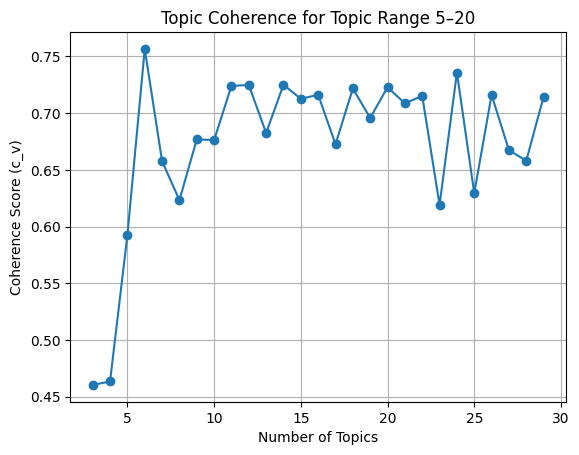

In [ ]:
#plotting

import matplotlib.pyplot as plt

x, y = zip(*coherence_scores)
plt.plot(x, y, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (c_v)")
plt.title("Topic Coherence for Topic Range 5–20")
plt.grid(True)
plt.show()


## Visulializing Topics

In [ ]:
tm_nolemma

,Topic,Count,Name,Representation,Representative_Docs
0,-1,5030,-1_money_life_man_real,"[money, life, man, real, work, men, jail, guys...",[with one click get thousands of new_qualified...
1,0,4342,0_white_trump_jail_country,"[white, trump, jail, country, man, matrix, tru...",[first they come for us . coming for all of yo...
2,1,1015,1_ai_machines_bitcoin_replace,"[ai, machines, bitcoin, replace, money, machin...",[great_painters and heroes_alike and look back...
3,2,920,2_women_men_man_woman,"[women, men, man, woman, pain, life, children,...","[if you look at any superhero , his life is ha..."
4,3,109,3_inside_unfair_advantage_emergency_meeting_ta...,"[inside, unfair_advantage, emergency_meeting, ...",[an exclusive_stream for people who are inside...
5,4,65,4_fire_blood_plastic_vitamins_vitamin,"[fire_blood, plastic, vitamins, vitamin, suppl...",[if your notice that today 's emergency knee h...


In [ ]:
topic_model.get_topic(4)

[('fire_blood', 1.0052879224342626),
 ('plastic', 0.8955360675161769),
 ('vitamins', 0.8149219907387661),
 ('vitamin', 0.8061597529701643),
 ('supplement', 0.7770442851984737),
 ('micro_plastics', 0.6943013286995184),
 ('tastes', 0.6896838728093585),
 ('taste', 0.6337590438911538),
 ('yellow', 0.6311274447973504),
 ('amino_acids', 0.6121505012733879),
 ('flavoring', 0.596072307097833),
 ('vitamin_b', 0.5779955660006053),
 ('scoop', 0.5775573255066698),
 ('supplements', 0.5736125188167674),
 ('meat', 0.5722414856030572)]

In [ ]:
topic_model.visualize_barchart() #top_n_topics=20

In [ ]:
topic_model.visualize_hierarchy()

In [ ]:
topic_model.visualize_topics()

In [ ]:
#50
topic_model.get_representative_docs(topic=4)

["if your notice that today 's emergency knee has been super high energy . it 's both to you by fire_blood . it is . in fact , the best thing about fire_blood is how yellow it makes your piss . you know that ? have you noticed ? make sure piss super yellow . fire makes a piss yellow . like a man , manly yellow , piss . none of that clear gay little girl pissed man fist . and the reason for that is very simple . we have all of the vitamins minerals and amino_acids , the body you can need and once to give me scoop of fire_blood . and like a man , evade , excessive . body the god of person is gon na take a supplement which tastes_disgusting with those slavery whatsoever all or you kinda something that tastes like cookie_crumble , and your peas do n't even yellow because there 's only a little_bit of vitamins in it .",
 "and the reason for that is very simple . we have all of the vitamin minerals and amino_acids , the body can need and once the union scoop fire . and like a man , made it e

## Exploring Documents

In [ ]:
docs_info = topic_model.get_document_info(documents)

In [ ]:



topic_3_docs = docs_info[docs_info["Topic"] == 0]
#topic_3_docs

df_sorted = topic_3_docs.sort_values(by="Probability", ascending=False)
df_sorted


,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
47,"you can find us here on rumble , make sure you...",0,0_white_trump_jail_country,"[white, trump, jail, country, man, matrix, tru...",[first they come for us . coming for all of yo...,white - trump - jail - country - man - matrix ...,1.000000,False
11478,this is the division . a britain that is proud...,0,0_white_trump_jail_country,"[white, trump, jail, country, man, matrix, tru...",[first they come for us . coming for all of yo...,white - trump - jail - country - man - matrix ...,1.000000,False
11475,and the foreign_policy for britain working clo...,0,0_white_trump_jail_country,"[white, trump, jail, country, man, matrix, tru...",[first they come for us . coming for all of yo...,white - trump - jail - country - man - matrix ...,1.000000,False
11470,a stronger future for britain is laying to fou...,0,0_white_trump_jail_country,"[white, trump, jail, country, man, matrix, tru...",[first they come for us . coming for all of yo...,white - trump - jail - country - man - matrix ...,1.000000,False
11466,it hurts britain 's competitiveness it hurts t...,0,0_white_trump_jail_country,"[white, trump, jail, country, man, matrix, tru...",[first they come for us . coming for all of yo...,white - trump - jail - country - man - matrix ...,1.000000,False
...,...,...,...,...,...,...,...,...
2432,"we found something , just minute it and then w...",0,0_white_trump_jail_country,"[white, trump, jail, country, man, matrix, tru...",[first they come for us . coming for all of yo...,white - trump - jail - country - man - matrix ...,0.159733,False
2240,but now we 've had five hundred pickup trucks ...,0,0_white_trump_jail_country,"[white, trump, jail, country, man, matrix, tru...",[first they come for us . coming for all of yo...,white - trump - jail - country - man - matrix ...,0.155276,False
2397,"this substance , i can buy it up dirt cheap an...",0,0_white_trump_jail_country,"[white, trump, jail, country, man, matrix, tru...",[first they come for us . coming for all of yo...,white - trump - jail - country - man - matrix ...,0.144843,False
2456,"like , yeah , that 's great , man . he ca n't ...",0,0_white_trump_jail_country,"[white, trump, jail, country, man, matrix, tru...",[first they come for us . coming for all of yo...,white - trump - jail - country - man - matrix ...,0.142628,False


In [ ]:

import random

def sample_snippets_by_topic(docs_info, topic_number=None, n=10, min_prob=0.0, seed=42):
    """
    Sample `n` random document snippets from a topic for codebook development.

    Parameters:
    - docs_info: DataFrame from topic_model.get_document_info()
    - topic_number: specific topic to sample from (int). If None, samples from all topics.
    - n: number of snippets to sample (int)
    - min_prob: minimum probability threshold to ensure relevance (float, 0.0–1.0)
    - seed: random seed for reproducibility (int)

    Returns:
    - DataFrame of sampled snippets
    """
    random.seed(seed)
    df = docs_info.copy()

    if topic_number is not None:
        df = df[df["Topic"] == topic_number]

    df = df[df["Probability"] >= min_prob]

    if len(df) == 0:
        print("No snippets found for this filter.")
        return pd.DataFrame()

    sample_indices = random.sample(list(df.index), min(n, len(df)))
    return df.loc[sample_indices][["Document", "Topic", "Probability"]].reset_index(drop=True)


In [ ]:

sample = sample_snippets_by_topic(docs_info, topic_number=0, n=35, min_prob=0.3)


In [ ]:
sample.iloc[34]["Document"]

"count the black people because i just see white people cheering . not only are they enduring this . not only are they being forced to suffer this . no . they 're happy about this . they 're entertained by this . they 're like , yeah . yeah . yeah . do it . do it . so over . islam is not ruining your countries . the invaders are n't ruining your countries . these people are ruining your countries . these people . the traders , your ... the people who have betrayed you . this is why your countries are over and they 're gon na be conquered because power vacuums must be filled . and we 've realized that there 's no masculine resistance . we 're just gon na come and take your all your shit . america 's a rich country . they must defend it really well . no . nobody defends it . a too_busy drinking wine piss from a drag queen ? cool ."

In [ ]:
doc = df_sorted.iloc[0]['Document']

doc

"you can find us here on rumble , make sure you sub to us a rumble and also we 're on get . so you can sub to us on get . here 's my get though website cobra_tape dot_com and sign up to the email_list . in fact , we 're gon na take a little break because i , this is really important , guys . we 're fighting the make is really important . we need your help for once we 're asking you to help us in this revolution . it 's a revolution . so guys , take a minute , sub on rubble , then go to get , sign up to get her follow us on get . i 'll just put you there get at corporate or get at telus , and then go to cobra_tape dot_com and sign up to the email_list . so while you do that , we 're gon na play this video because this video just makes me smile because it 's so true . i going nowhere ."

In [ ]:
#saving snippets
snippets = pd.DataFrame(columns=["Topic", "Snippet"])

In [ ]:
sample = sample_snippets_by_topic(docs_info, topic_number=3, n=35, min_prob=0.3)
snippets["Snippet"] = sample["Document"].tolist()
snippets["Topic"] = [3] * 35

In [ ]:
snippets.head()

,Topic,Snippet
0,3,and exclusive_stream for people who are inside...
1,3,"in fact , can avoid nearly all of life 's prob..."
2,3,and then at the end we 're gon na say for the ...
3,3,an exclusive_stream for people who are inside ...
4,3,excluding dark . think give away . i 'll open ...


In [ ]:
#Adding video name to snippet
file_path = "/content/drive/MyDrive/Emergency_Meeting_Deepgram/topic_4.csv"
topic_4 = pd.read_csv(file_path)

In [ ]:
topic_4.head()

,Topic,Snippet
0,4,"white described the flavor , but ... now when ..."
1,4,"but we have un unmatched first cassie , which ..."
2,4,we 've been up for twenty two hours . we have ...
3,4,everybody 's asleep . zoom my face . i put i p...
4,4,there 's such the thing as having yours . that...


In [ ]:
def vid_matching(text):
  matches = chunked_df[chunked_df['bigram_nolemmatext'] == text]
  video = matches["doc_id"].iloc[0]
  return video

In [ ]:
topic_4['Video'] = topic_4['Snippet'].apply(vid_matching)

In [ ]:
topic_4.head()

,Topic,Snippet,Video
0,4,"white described the flavor , but ... now when ...",episode-41-lockdown.txt
1,4,"but we have un unmatched first cassie , which ...",episode-8-awakened-warrior.txt
2,4,we 've been up for twenty two hours . we have ...,episode-86-the-fate-of-america.txt
3,4,everybody 's asleep . zoom my face . i put i p...,episode-44-black-swan.txt
4,4,there 's such the thing as having yours . that...,episode-44-black-swan.txt


In [ ]:
file_path = "/content/drive/MyDrive/Emergency_Meeting_Deepgram/topic_4.csv"
topic_4.to_csv(file_path, index=False)

## Most Related Video

In [ ]:
file_path = "/content/drive/MyDrive/Emergency_Meeting_Deepgram/chunked_df.csv"

chunked_df = pd.read_csv(file_path)

In [ ]:
chunked_df.head()

,doc_id,chunk_id,text,lower_text,bigram_nolemmatext
0,the-matrix-attacks..txt,0,"Controversial influencer, Andrew Tape. Andrew ...","controversial influencer, andrew tape. andrew ...","controversial_influencer , andrew tape . andre..."
1,the-matrix-attacks..txt,1,"Imagine shooting a man with your last bullet, ...","imagine shooting a man with your last bullet, ...","imagine_shooting a man with your last_bullet ,..."
2,the-matrix-attacks..txt,2,They fired the bullet that never fails. It bou...,they fired the bullet that never fails. it bou...,they fired the bullet that never fails . it bo...
3,the-matrix-attacks..txt,3,They need us and they use us. But the second w...,they need us and they use us. but the second w...,they need us and they use us . but the second ...
4,the-matrix-attacks..txt,4,Andrew tape is a self described miso is is thi...,andrew tape is a self described miso is is thi...,andrew tape is a self described miso is is thi...


In [ ]:
documents = chunked_df["bigram_nolemmatext"].tolist()

In [ ]:
#Creating new dataframe

top_vids = pd.DataFrame(columns=["Name", "Video1"])

In [ ]:
top_vids["Name"]= tm_nolemma["Name"]

top_vids

,Name,Video1
0,-1_money_life_man_real,NaN
1,0_white_trump_jail_country,NaN
2,1_ai_machines_bitcoin_replace,NaN
3,2_women_men_man_woman,NaN
4,3_inside_unfair_advantage_emergency_meeting_ta...,NaN
5,4_fire_blood_plastic_vitamins_vitamin,NaN


In [ ]:
videos = chunked_df["doc_id"].unique()

result = {item: 0 for item in videos}


In [ ]:
docs_info = topic_model.get_document_info(documents)

topic_list = docs_info[docs_info["Topic"] == 2]["Document"]


In [ ]:

def matching(text):
  matches = chunked_df[chunked_df['bigram_nolemmatext'] == text]
  video = matches["doc_id"].iloc[0]

  #print(video + "-------")

  for video in matches["doc_id"]:
        result[video] = result.get(video, 0) + 1

  return result

In [ ]:
for doc in topic_list:
  matching(doc)

In [ ]:
sorted_scores = dict(sorted(result.items(), key=lambda x: x[1], reverse=True))
sorted_scores

{'episode-76-gyal-dem.txt': 77,
 'episode-14.txt': 51,
 'episode-5-family-friends.txt': 36,
 'war-smiles.txt': 34,
 'episode-95-100k-party.txt': 30,
 'em-battlegrounds.txt': 29,
 'episode-35-mind-aikido.txt': 29,
 'episode-85-the-portal.txt': 25,
 'episode-87-were-so-back.txt': 23,
 'episode-88-back-to-reality.txt': 23,
 'episode-86-the-fate-of-america.txt': 22,
 'episode-15.txt': 21,
 'episode-90-happy-birthday-to-the-real-world.txt': 20,
 'episode-7-the-master-plan.txt': 19,
 'episode-73-keep-it-simple.txt': 19,
 'episode-78-overton-window.txt': 18,
 'episode-92-in-the-trenches.txt': 18,
 'episode-93-me-too.txt': 18,
 'episode-91-case-dismissed.txt': 17,
 'episode-52-do-you-have-a-sword.txt': 16,
 'episode-80-why-you-lose.txt': 16,
 'episode-100-tate-for-prime-minister.txt': 16,
 'episode-36-smackdown.txt': 15,
 'episode-81-uptober.txt': 15,
 'episode-99-2024-time-vacuum.txt': 15,
 'yeeha.txt': 14,
 'episode-47-positive-orgones.txt': 14,
 'episode-48-unfair-advantage.txt': 14,
 'epis

In [ ]:
top_vids

,Name,Video1,Video2
0,-1_money_life_man_real,NaN,NaN
1,0_white_trump_jail_country,episode-86-the-fate-of-america.txt,NaN
2,1_ai_machines_bitcoin_replace,episode-82-huge-announcement.txt,NaN
3,2_women_men_man_woman,episode-76-gyal-dem.txt,NaN
4,3_inside_unfair_advantage_emergency_meeting_ta...,episode-82-huge-announcement.txt,episode-48-unfair-advantage.txt
5,4_fire_blood_plastic_vitamins_vitamin,episode-55-plastic-balls.txt,NaN


In [ ]:
top_key = max(result, key=result.get)
print(top_key)

episode-82-huge-announcement.txt


In [ ]:
#Adding to the dictionary

top_vids.loc[4, "Video2"] = "episode-48-unfair-advantage.txt"

In [ ]:
file_path = "/content/drive/MyDrive/Emergency_Meeting_Deepgram/top_vid.csv"
top_vids.to_csv(file_path, index=False)

## Removing duplicates?

In [ ]:
file_path = "/content/drive/MyDrive/Emergency_Meeting_Deepgram/chunked_df.csv"

chunked_df = pd.read_csv(file_path)

In [ ]:
chunked_df.shape

(11481, 5)

In [ ]:
chunked_df.head()

,doc_id,chunk_id,text,lower_text,bigram_nolemmatext
0,the-matrix-attacks..txt,0,"Controversial influencer, Andrew Tape. Andrew ...","controversial influencer, andrew tape. andrew ...","controversial_influencer , andrew tape . andre..."
1,the-matrix-attacks..txt,1,"Imagine shooting a man with your last bullet, ...","imagine shooting a man with your last bullet, ...","imagine_shooting a man with your last_bullet ,..."
2,the-matrix-attacks..txt,2,They fired the bullet that never fails. It bou...,they fired the bullet that never fails. it bou...,they fired the bullet that never fails . it bo...
3,the-matrix-attacks..txt,3,They need us and they use us. But the second w...,they need us and they use us. but the second w...,they need us and they use us . but the second ...
4,the-matrix-attacks..txt,4,Andrew tape is a self described miso is is thi...,andrew tape is a self described miso is is thi...,andrew tape is a self described miso is is thi...


In [ ]:
df_no_duplicates = chunked_df[~chunked_df['lower_text'].duplicated(keep=False)]

In [ ]:
df_no_duplicates.shape

(11479, 5)